In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from typing import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve,classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from mlxtend.classifier import StackingCVClassifier

In [3]:
df=pd.read_csv(r'D:\DEPI\learning\linear regression\Smart Health Risk Predictor\heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

<Axes: >

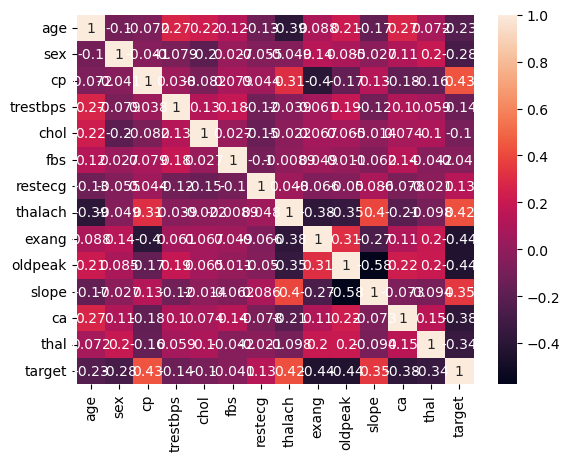

In [6]:
sns.heatmap(df.corr(), annot=True)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [9]:
x = df.drop('target', axis=1)
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [10]:


print(y_test.unique())
Counter(y_train)

[1 0]


Counter({1: 419, 0: 401})

In [11]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [12]:
model1 = 'LogisticRegression'
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print('Confusion Matrix for Logistic Regression:')
print(confusion_matrix(y_test, y_pred))
print('Accuracy Score for Logistic Regression:')
lr_acc_score = accuracy_score(y_test, y_pred)
print(accuracy_score(y_test, y_pred))
print('Classification Report for Logistic Regression:')
print(classification_report(y_test, y_pred))

Confusion Matrix for Logistic Regression:
[[ 77  21]
 [  7 100]]
Accuracy Score for Logistic Regression:
0.8634146341463415
Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        98
           1       0.83      0.93      0.88       107

    accuracy                           0.86       205
   macro avg       0.87      0.86      0.86       205
weighted avg       0.87      0.86      0.86       205



In [13]:
model2 = 'Naive Bayes'
nb = GaussianNB()
nb.fit(x_train, y_train)
y_pred_nb = nb.predict(x_test)
print('Confusion Matrix for Naive Bayes:')
print(confusion_matrix(y_test, y_pred_nb))
print('Accuracy Score for Naive Bayes:')
nb_acc_score = accuracy_score(y_test, y_pred_nb)
print(accuracy_score(y_test, y_pred_nb))
print('Classification Report for Naive Bayes:')
print(classification_report(y_test, y_pred_nb))

Confusion Matrix for Naive Bayes:
[[79 19]
 [11 96]]
Accuracy Score for Naive Bayes:
0.8536585365853658
Classification Report for Naive Bayes:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84        98
           1       0.83      0.90      0.86       107

    accuracy                           0.85       205
   macro avg       0.86      0.85      0.85       205
weighted avg       0.86      0.85      0.85       205



In [14]:
model3 ='random forest'
rf = RandomForestClassifier(max_depth=4,
    min_samples_split=5,
    n_estimators=100)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print('Confusion Matrix for Random Forest:')
print(confusion_matrix(y_test, y_pred_rf))
print('Accuracy Score for Random Forest:')
rf_acc_score = accuracy_score(y_test, y_pred_rf)
print(accuracy_score(y_test, y_pred_rf))
print('Classification Report for Random Forest:')
print(classification_report(y_test, y_pred_rf))

Confusion Matrix for Random Forest:
[[ 85  13]
 [  3 104]]
Accuracy Score for Random Forest:
0.9219512195121952
Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.97      0.87      0.91        98
           1       0.89      0.97      0.93       107

    accuracy                           0.92       205
   macro avg       0.93      0.92      0.92       205
weighted avg       0.93      0.92      0.92       205



In [15]:
from xgboost import XGBClassifier

model4= 'Gradient Boosting'
xgb= XGBClassifier(learning_rate=0.01, n_estimators=25, max_depth=15,gamma=0.6, subsample=0.52,colsample_bytree=0.6,seed=27, 
                    reg_lambda=2, booster='dart', colsample_bylevel=0.6, colsample_bynode=0.5)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
print('Confusion Matrix for XGBoost:')
print(confusion_matrix(y_test, y_pred_xgb))
print('Accuracy Score for XGBoost:')
xgb_acc_score = accuracy_score(y_test, y_pred_xgb)
print(accuracy_score(y_test, y_pred_xgb))
print('Classification Report for XGBoost:')
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix for XGBoost:
[[ 86  12]
 [  3 104]]
Accuracy Score for XGBoost:
0.926829268292683
Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        98
           1       0.90      0.97      0.93       107

    accuracy                           0.93       205
   macro avg       0.93      0.92      0.93       205
weighted avg       0.93      0.93      0.93       205



In [16]:
model5 = 'KNN'
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
print('Confusion Matrix for KNN:')
print(confusion_matrix(y_test, y_pred_knn))
print('Accuracy Score for KNN:')
knn_acc_score = accuracy_score(y_test, y_pred_knn)
print(accuracy_score(y_test, y_pred_knn))
print('Classification Report for KNN:')
print(classification_report(y_test, y_pred_knn))


Confusion Matrix for KNN:
[[84 14]
 [10 97]]
Accuracy Score for KNN:
0.8829268292682927
Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88        98
           1       0.87      0.91      0.89       107

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



In [17]:
model6 = 'Decision Tree'
dt = DecisionTreeClassifier(criterion = 'entropy',random_state=0,max_depth = 6)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
print('Confusion Matrix for Decision Tree:')
print(confusion_matrix(y_test, y_pred_dt))
print('Accuracy Score for Decision Tree:')
dt_acc_score = accuracy_score(y_test, y_pred_dt)
print(accuracy_score(y_test, y_pred_dt))
print('Classification Report for Decision Tree:')
print(classification_report(y_test, y_pred_dt))

Confusion Matrix for Decision Tree:
[[95  3]
 [ 8 99]]
Accuracy Score for Decision Tree:
0.9463414634146341
Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95        98
           1       0.97      0.93      0.95       107

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95       205



In [18]:
model7 = 'SVM'
svm = SVC(kernel='rbf', C=2)
svm.fit(x_train, y_train)
y_pred_svm = svm.predict(x_test)
print('Confusion Matrix for SVM:')
print(confusion_matrix(y_test, y_pred_svm))
print('Accuracy Score for SVM:')
svc_acc_score = accuracy_score(y_test, y_pred_svm)
print(accuracy_score(y_test, y_pred_svm))
print('Classification Report for SVM:')
print(classification_report(y_test, y_pred_svm))

Confusion Matrix for SVM:
[[ 94   4]
 [  0 107]]
Accuracy Score for SVM:
0.9804878048780488
Classification Report for SVM:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        98
           1       0.96      1.00      0.98       107

    accuracy                           0.98       205
   macro avg       0.98      0.98      0.98       205
weighted avg       0.98      0.98      0.98       205



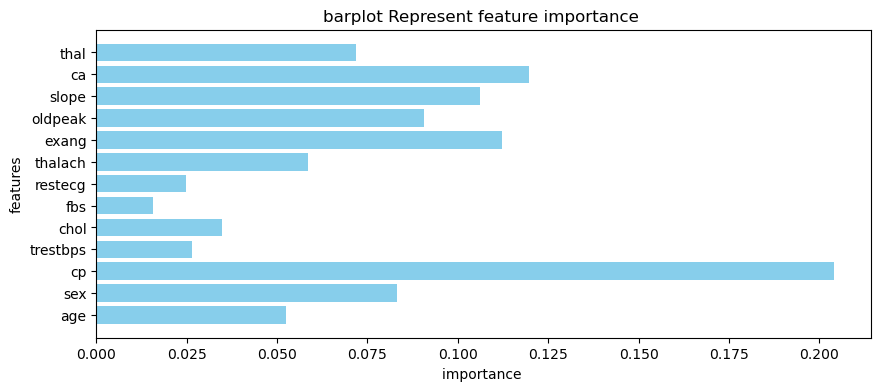

In [19]:
imp_feature = pd.DataFrame({'Feature': ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'], 'Importance': xgb.feature_importances_})
plt.figure(figsize=(10,4))
plt.title("barplot Represent feature importance ")
plt.xlabel("importance ")
plt.ylabel("features")
plt.barh(imp_feature['Feature'], imp_feature['Importance'], color='skyblue')
plt.show()

In [20]:
model_ev = pd.DataFrame({'Model': ['Logistic Regression','Naive Bayes','Random Forest','Extreme Gradient Boost',
                    'K-Nearest Neighbour','Decision Tree','Support Vector Machine'], 'Accuracy': [lr_acc_score*100,
                    nb_acc_score*100,rf_acc_score*100,xgb_acc_score*100,knn_acc_score*100,dt_acc_score*100,svc_acc_score*100]})
model_ev

,Model,Accuracy
0,Logistic Regression,86.341463
1,Naive Bayes,85.365854
2,Random Forest,92.195122
3,Extreme Gradient Boost,92.682927
4,K-Nearest Neighbour,88.292683
5,Decision Tree,94.634146
6,Support Vector Machine,98.048780


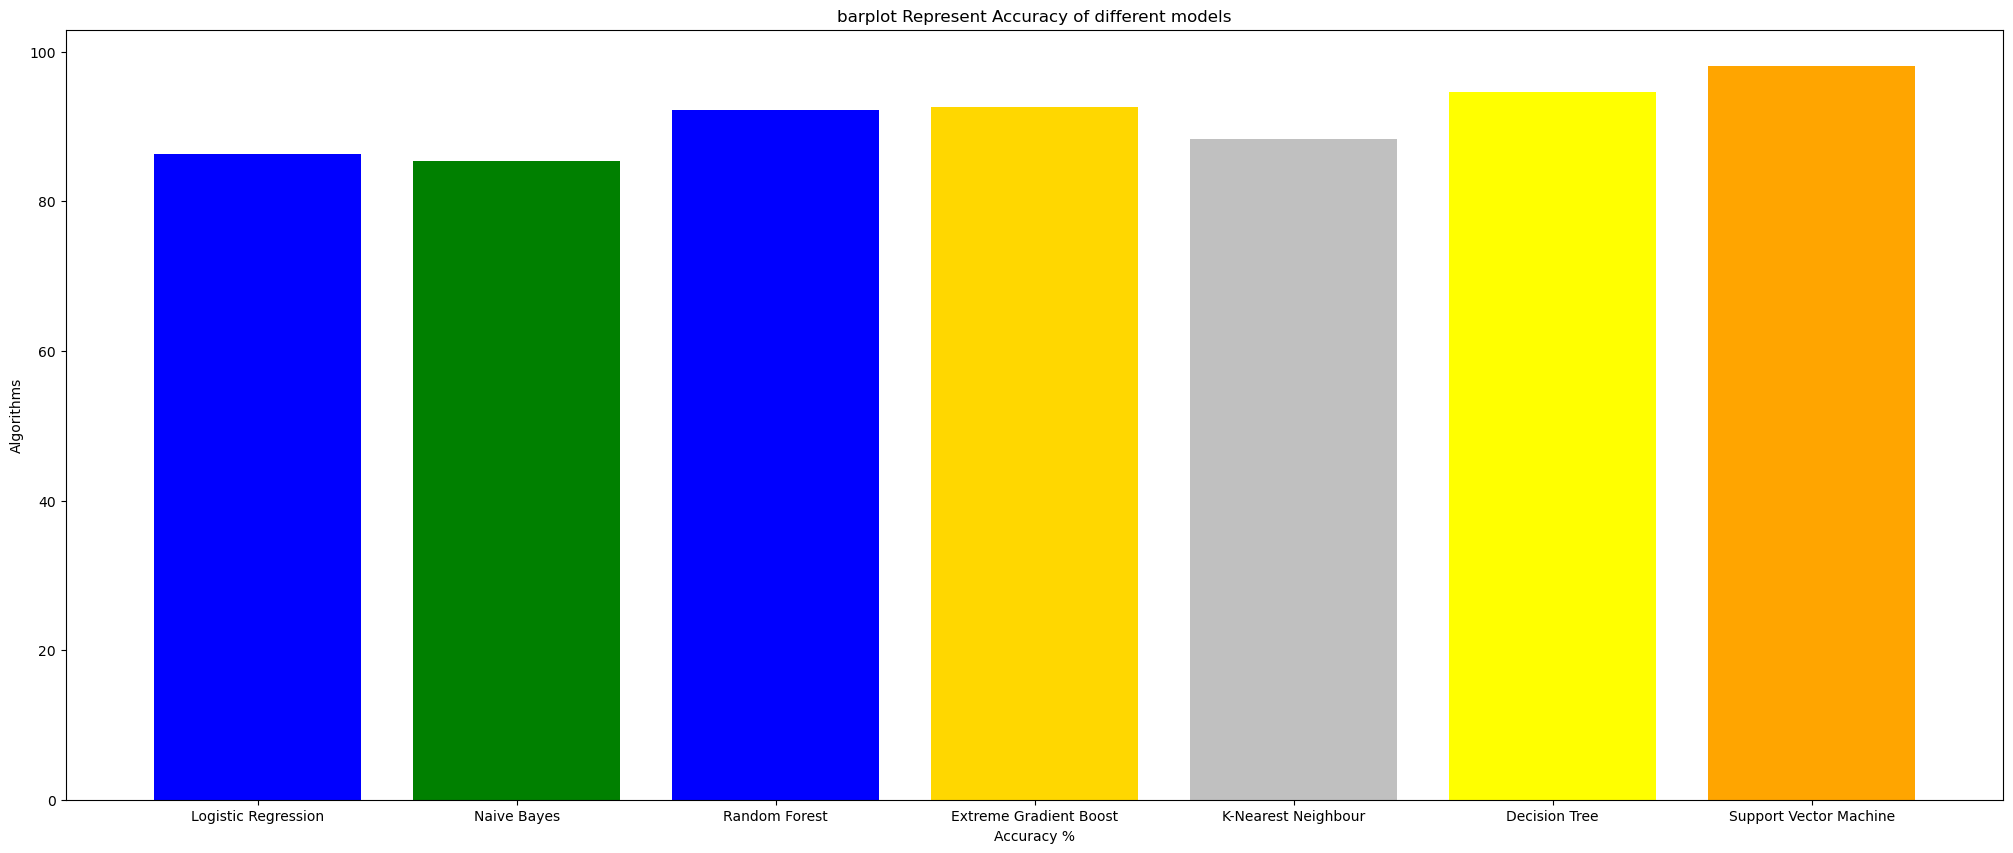

In [21]:
colors = ['blue','green','blue','gold','silver','yellow','orange',]
plt.figure(figsize=(25,10))
plt.title("barplot Represent Accuracy of different models")
plt.xlabel("Accuracy %")
plt.ylabel("Algorithms")
plt.bar(model_ev['Model'], model_ev['Accuracy'], color=colors)

plt.show()

In [25]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

stack.fit(x_train, y_train)

y_pred_stack = stack.predict(x_test)
print('Confusion Matrix for StackingClassifier:')
print(confusion_matrix(y_test, y_pred_stack))
print('Accuracy Score for StackingClassifier:')
print(accuracy_score(y_test, y_pred_stack))
print('Classification Report for StackingClassifier:')
print(classification_report(y_test, y_pred_stack))


Confusion Matrix for StackingClassifier:
[[ 88  10]
 [  5 102]]
Accuracy Score for StackingClassifier:
0.926829268292683
Classification Report for StackingClassifier:
              precision    recall  f1-score   support

           0       0.95      0.90      0.92        98
           1       0.91      0.95      0.93       107

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



In [26]:
import pickle

pickle.dump(xgb, open("xgb_model.pkl", "wb"))

In [28]:
feature_names = x.columns.tolist()

pickle.dump(feature_names, open("features.pkl", "wb"))

In [ ]:
def predict_heart_disease(model, scaler, data):
    data_scaled = scaler.transform([data])
    prob = model.predict_proba(data_scaled)[0][1]
    
    if prob > 0.7:
        risk = "High Risk "
    elif prob > 0.4:
        risk = "Medium Risk "
    else:
        risk = "Low Risk "
        
    return prob, risk

In [30]:
pickle.dump(scaler, open("scaler.pkl", "wb"))